In [12]:
from statistics import linear_regression

from pandas.conftest import axis

d = {
    "rollNO":[1,2,3],
    "Student" : ["a","b","c"],
    "FSD-2":[96,78,12],
    "Python-2":[91,95,99],
    "TOC":[77,89,67],
    "COA":[67,78,89],
    "DM":[98,45,19]
}
import  pandas as pd
df =  pd.DataFrame(d)
df

,rollNO,Student,FSD-2,Python-2,TOC,COA,DM
0,1,a,96,91,77,67,98
1,2,b,78,95,89,78,45
2,3,c,12,99,67,89,19


In [13]:
df["Total"] = df["FSD-2"] + df["TOC"] + df["COA"] + df["DM"]+df["Python-2"]


In [14]:
df["PER"] = df["Total"]/5

In [15]:
import  numpy as np
df["Grade"] = np.where(df['PER']>=80,"DISTINCTION",np.where(df["PER"]<60,"Second Class","First Class"))

In [16]:
df

,rollNO,Student,FSD-2,Python-2,TOC,COA,DM,Total,PER,Grade
0,1,a,96,91,77,67,98,429,85.8,DISTINCTION
1,2,b,78,95,89,78,45,385,77.0,First Class
2,3,c,12,99,67,89,19,286,57.2,Second Class


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rollNO    3 non-null      int64  
 1   Student   3 non-null      str    
 2   FSD-2     3 non-null      int64  
 3   Python-2  3 non-null      int64  
 4   TOC       3 non-null      int64  
 5   COA       3 non-null      int64  
 6   DM        3 non-null      int64  
 7   Total     3 non-null      int64  
 8   PER       3 non-null      float64
 9   Grade     3 non-null      str    
dtypes: float64(1), int64(7), str(2)
memory usage: 372.0 bytes


In [19]:
df.drop("Student",axis=1,inplace=True)

In [20]:
df

,rollNO,FSD-2,Python-2,TOC,COA,DM,Total,PER,Grade
0,1,96,91,77,67,98,429,85.8,DISTINCTION
1,2,78,95,89,78,45,385,77.0,First Class
2,3,12,99,67,89,19,286,57.2,Second Class


In [22]:
pd.get_dummies(df,drop_first=True)

,rollNO,FSD-2,Python-2,TOC,COA,DM,Total,PER,Grade_First Class,Grade_Second Class
0,1,96,91,77,67,98,429,85.8,False,False
1,2,78,95,89,78,45,385,77.0,True,False
2,3,12,99,67,89,19,286,57.2,False,True


In [25]:
df = pd.read_csv("/home/mihir/python-projects/Python-2_26-main/Dataset-1/olympic100m.csv")
df

,year,time
0,1896,12.00
1,1900,11.00
2,1904,11.00
3,1906,11.20
4,1908,10.80
5,1912,10.80
6,1920,10.80
7,1924,10.60
8,1928,10.80
9,1932,10.30


In [26]:
df.head()

,year,time
0,1896,12.0
1,1900,11.0
2,1904,11.0
3,1906,11.2
4,1908,10.8


In [27]:
df.tail()

,year,time
24,2000,9.87
25,2004,9.85
26,2008,9.69
27,2012,9.63
28,2016,9.81


In [28]:
import  sklearn

In [32]:
x = df[["year"]] # always in DATAFRAME
y = df["time"] # always in series

In [43]:
from   sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
yPred = model.predict(x)

In [45]:
yPred

array([11.12455601, 11.07301534, 11.02147467, 10.99570434, 10.969934  ,
       10.91839333, 10.81531199, 10.76377132, 10.71223065, 10.66068998,
       10.60914931, 10.45452731, 10.40298664, 10.35144597, 10.2999053 ,
       10.24836463, 10.19682396, 10.14528329, 10.09374262, 10.04220195,
        9.99066128,  9.93912061,  9.88757994,  9.83603927,  9.7844986 ,
        9.73295793,  9.68141726,  9.62987659,  9.57833592])

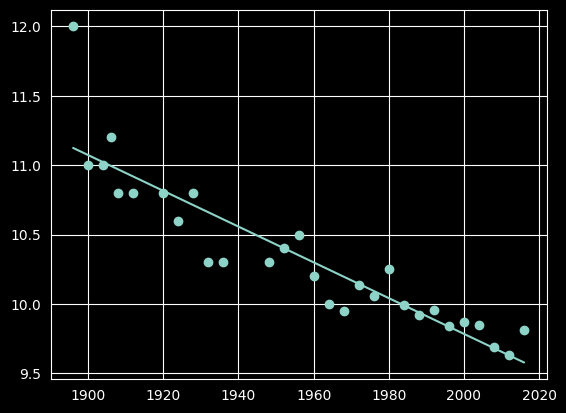

In [46]:
import  matplotlib.pyplot as plt
plt.scatter(x,y)
plt.plot(x,yPred)

In [50]:
Y_2032 = model.predict([[2032]])
print(Y_2032)

[9.37217324]


/home/mihir/python-projects/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [51]:
df = pd.read_csv("/home/mihir/python-projects/Python-2_26-main/Dataset-1/car data.csv")

In [53]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [62]:
df.drop(columns=["Owner"],inplace=True)

In [63]:
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual
...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual


In [64]:
df = pd.get_dummies(df,drop_first=True)

In [65]:
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,False,True,False,True
1,2013,4.75,9.54,43000,True,False,False,True
2,2017,7.25,9.85,6900,False,True,False,True
3,2011,2.85,4.15,5200,False,True,False,True
4,2014,4.60,6.87,42450,True,False,False,True
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,True,False,False,True
297,2015,4.00,5.90,60000,False,True,False,True
298,2009,3.35,11.00,87934,False,True,False,True
299,2017,11.50,12.50,9000,True,False,False,True


In [67]:
y = df["Selling_Price"]
x = df.drop("Selling_Price",axis=1)

In [68]:
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,False,True,False,True
1,2013,4.75,9.54,43000,True,False,False,True
2,2017,7.25,9.85,6900,False,True,False,True
3,2011,2.85,4.15,5200,False,True,False,True
4,2014,4.60,6.87,42450,True,False,False,True
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,True,False,False,True
297,2015,4.00,5.90,60000,False,True,False,True
298,2009,3.35,11.00,87934,False,True,False,True
299,2017,11.50,12.50,9000,True,False,False,True


In [84]:
from  sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [85]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test)


(240, 7)
(61, 7)
(240,)
258     8.40
154     0.50
227     2.55
126     0.90
268     4.80
       ...  
275    10.90
121     1.05
231     9.25
299    11.50
281     2.10
Name: Selling_Price, Length: 61, dtype: float64


In [86]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
yPred = model.predict(x_test)

In [88]:
yPred

array([ 7.77233375e+00,  7.78410230e-01,  1.83788336e+00,  2.04515462e+00,
        5.26656168e+00,  6.80826921e+00,  1.96133895e+01, -2.54085732e+00,
        9.82608412e-01,  4.39152987e+00,  3.62559718e-02,  8.80655637e+00,
        4.35076341e+00, -9.90321184e-01,  5.83738054e+00,  3.28102457e+00,
        4.47801022e+00, -7.93983656e+00,  2.58898838e+00,  5.80299134e+00,
        2.01238359e+00,  3.24254394e+00,  7.14599054e+00,  2.13876641e+01,
       -3.65982780e-01,  1.03486530e+00, -1.39644549e+00, -1.81930101e+00,
        1.51681609e+00, -3.46551105e+00, -2.96400259e-01,  1.41778102e+01,
        4.59682915e+00,  7.82029862e+00, -6.68298104e-03,  6.65871077e+00,
        2.62976414e+00,  3.55905564e+00,  1.59380427e+00,  4.19550453e+00,
        5.90605963e+00,  2.41857404e-01,  6.50958931e+00, -6.16853519e-02,
        1.05428848e+01,  3.28728063e+00, -9.13132748e-01,  4.81981325e+00,
        8.87020351e+00,  1.75658114e+00, -1.26274657e+00,  6.23389281e+00,
        8.27350821e-01,  

In [ ]:
# now give me the sell prize at 2034
